In [1]:
import os
import sys
import time
import math
import random
import glob
import socket
from pathlib import Path

# Quietly install timm if not present (e.g. Kaggle environment)
try:
    import timm
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print("HARDWARE ACCELERATION")
print("=" * 60)
if torch.cuda.is_available():
    print(f"Device Name      : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version     : {torch.version.cuda}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Total VRAM       : {total_mem:.2f} GB")
else:
    print("WARNING: CUDA is NOT available. Running on CPU.")
print(f"Active Device    : {device}")
print("=" * 60)

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

HARDWARE ACCELERATION
Device Name      : Tesla T4
CUDA Version     : 12.8
Total VRAM       : 14.56 GB
Active Device    : cuda


In [3]:
CLASS_NAMES = ["lung_aca", "lung_n", "lung_scc"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for idx, name in enumerate(CLASS_NAMES)}

def find_lung_dataset_root():
    search_roots = ["/kaggle/input", "./", "../input"]
    for base in search_roots:
        if not os.path.exists(base):
            continue
        for root, dirs, _ in os.walk(base):
            if all(cls_name in dirs for cls_name in CLASS_NAMES):
                return Path(root)
    raise FileNotFoundError(
        f"Could not locate LC25000 folders containing {CLASS_NAMES}."
    )

dataset_root = find_lung_dataset_root()
print(f"\n[INFO] Dataset located at: {dataset_root}")

all_file_paths = []
all_labels = []

for cls_name in CLASS_NAMES:
    cls_folder = dataset_root / cls_name
    img_paths = sorted(
        glob.glob(str(cls_folder / "*.jpeg")) +
        glob.glob(str(cls_folder / "*.jpg")) +
        glob.glob(str(cls_folder / "*.png"))
    )
    for p in img_paths:
        all_file_paths.append(p)
        all_labels.append(CLASS_TO_IDX[cls_name])

all_file_paths = np.array(all_file_paths)
all_labels = np.array(all_labels)

total_images = len(all_file_paths)
print(f"Total Images Found: {total_images:,}")

# Fixed Stratified 70/30 Split
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_file_paths,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
    stratify=all_labels
)

print(f"Training Set : {len(train_paths):,} (70%)")
print(f"Testing Set  : {len(test_paths):,} (30%)")


[INFO] Dataset located at: /kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets
Total Images Found: 15,000
Training Set : 10,500 (70%)
Testing Set  : 4,500 (30%)


In [4]:
class LC25000Dataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        image = Image.open(path).convert("RGB")
        label = self.labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

norm_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

BATCH_SIZE = 16
NUM_WORKERS = 2

train_dataset = LC25000Dataset(train_paths, train_labels, transform=norm_transform)
test_dataset = LC25000Dataset(test_paths, test_labels, transform=norm_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

In [5]:
PREVIOUS_BASELINE_MODEL = "GhostNet-100"
PREVIOUS_BASELINE_ACCURACY = 97.667

print("=" * 60)
print("PREVIOUS BASELINE RESULT")
print("=" * 60)
print(f"Model        : {PREVIOUS_BASELINE_MODEL}")
print(f"Accuracy     : {PREVIOUS_BASELINE_ACCURACY:.3f}%")
print("=" * 60)

PREVIOUS BASELINE RESULT
Model        : GhostNet-100
Accuracy     : 97.667%


In [6]:
def is_internet_available(host="8.8.8.8", port=53, timeout=2):
    try:
        socket.setdefaulttimeout(timeout)
        socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect((host, port))
        return True
    except (socket.timeout, OSError):
        return False

def build_ghostnet100(num_classes=3, weights_path=None):
    if weights_path and os.path.exists(weights_path):
        print(f"[INFO] Loading local weights from: {weights_path}")
        model = timm.create_model("ghostnet_100", pretrained=False, num_classes=num_classes)
        state_dict = torch.load(weights_path, map_location="cpu")
        state_dict = {k: v for k, v in state_dict.items() if not k.startswith("classifier")}
        model.load_state_dict(state_dict, strict=False)
        return model

    if is_internet_available():
        try:
            model = timm.create_model("ghostnet_100", pretrained=True, num_classes=num_classes)
            print("[INFO] Successfully loaded pretrained GhostNet-100 from Hugging Face.")
            return model
        except Exception as e:
            print(f"[WARNING] Download failed ({e}). Initializing without pretrained weights.")
    else:
        print("[WARNING] Offline mode: Initializing GhostNet-100 with random weights.")

    return timm.create_model("ghostnet_100", pretrained=False, num_classes=num_classes)


class GhostNetVisionTransformer(nn.Module):
    """
    Hybrid Architecture:
    Input Image (B, 3, 224, 224)
          ↓
    GhostNet-100 Backbone (forward_features)
          ↓
    Feature Maps (B, 960, 7, 7)
          ↓
    1x1 Conv Projection → Patch/Token Sequence (B, 49, 256)
          ↓
    + Learnable Positional Embedding & Dropout (B, 49, 256)
          ↓
    Vision Transformer Encoder (1 Layer, 4 Heads, Dim 256, FFN 512, Dropout 0.1)
          ↓
    Global Mean Pooling across 49 Tokens (B, 256)
          ↓
    Layer Normalization (B, 256)
          ↓
    Fully Connected Classification Layer (B, 3)
          ↓
    3 Classes (lung_aca, lung_n, lung_scc)
    """
    def __init__(
        self,
        num_classes=3,
        weights_path=None,
        embed_dim=256,
        num_heads=4,
        num_layers=1,
        dim_feedforward=512,
        dropout=0.1
    ):
        super().__init__()
        self.num_classes = num_classes
        self.embed_dim = embed_dim

        # 1. GhostNet-100 Backbone
        self.backbone = build_ghostnet100(num_classes=num_classes, weights_path=weights_path)

        # Dynamically determine feature dimensions
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            feat = self.backbone.forward_features(dummy)
            in_channels = feat.shape[1]                       # 960 for GhostNet-100
            self.num_patches = feat.shape[2] * feat.shape[3]  # 7 * 7 = 49

        # 2. Linear projection from feature map channels to embed_dim (256)
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)

        # 3. Learnable Positional Embedding & Dropout
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.pos_drop = nn.Dropout(p=dropout)

        # 4. Vision Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

        # 5. Fully Connected Classification Head
        self.classifier = nn.Linear(embed_dim, num_classes)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, x):
        # x: (B, 3, 224, 224)
        feat = self.backbone.forward_features(x)            # (B, 960, 7, 7)
        feat = self.proj(feat)                             # (B, 256, 7, 7)

        # Convert Feature Maps -> Patch/Token Sequence: (B, 256, 49) -> (B, 49, 256)
        tokens = feat.flatten(2).transpose(1, 2)

        # Add Positional Embedding (with dynamic interpolation if needed)
        if tokens.shape[1] != self.pos_embed.shape[1]:
            pos_embed = F.interpolate(
                self.pos_embed.permute(0, 2, 1),
                size=tokens.shape[1],
                mode="linear",
                align_corners=False
            ).permute(0, 2, 1)
        else:
            pos_embed = self.pos_embed

        tokens = tokens + pos_embed
        tokens = self.pos_drop(tokens)

        # Vision Transformer Encoder
        out = self.transformer(tokens)                      # (B, 49, 256)

        # Global / Mean Pooling over sequence tokens
        pooled = out.mean(dim=1)                            # (B, 256)
        pooled = self.norm(pooled)

        # Fully Connected Classification Layer
        logits = self.classifier(pooled)                    # (B, 3)
        return logits


# Verify Architecture Parameters
sample_hybrid = GhostNetVisionTransformer(
    num_classes=3,
    embed_dim=256,
    num_heads=4,
    num_layers=1,
    dim_feedforward=512,
    dropout=0.1
)
hybrid_total_params = sum(p.numel() for p in sample_hybrid.parameters())
hybrid_trainable_params = sum(p.numel() for p in sample_hybrid.parameters() if p.requires_grad)
hybrid_param_size_mb = sum(p.numel() * p.element_size() for p in sample_hybrid.parameters()) / (1024**2)

print("=" * 60)
print("HYBRID MODEL ARCHITECTURE VERIFICATION")
print("=" * 60)
print(f"Total Parameters             : {hybrid_total_params:,}")
print(f"Trainable Parameters         : {hybrid_trainable_params:,}")
print(f"Model Parameter Size in RAM  : {hybrid_param_size_mb:.2f} MB")
print("=" * 60)

model.safetensors: reconstructing file:   0%|          |  0.00B / 20.9MB            

model.safetensors: downloading bytes:           |  0.00B            

[INFO] Successfully loaded pretrained GhostNet-100 from Hugging Face.
HYBRID MODEL ARCHITECTURE VERIFICATION
Total Parameters             : 4,692,298
Trainable Parameters         : 4,692,298
Model Parameter Size in RAM  : 17.90 MB


/tmp/ipykernel_22/2543428495.py:96: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [7]:
def evaluate_model(model, test_loader):
    model.eval()
    model.to(device)

    all_targets = []
    all_preds = []
    all_probs = []

    # Warm-up pass
    with torch.no_grad():
        for i, (images, _) in enumerate(test_loader):
            images = images.to(device)
            _ = model(images)
            if i >= 2:
                break

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_inf = time.perf_counter()

    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    total_inf_time = time.perf_counter() - start_inf

    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    num_test_samples = len(all_targets)
    avg_inf_time_per_image_ms = (total_inf_time / num_test_samples) * 1000.0

    cm = confusion_matrix(all_targets, all_preds)
    specificities = []
    for i in range(len(CLASS_NAMES)):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec_i = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec_i)
    macro_specificity = np.mean(specificities)

    acc = accuracy_score(all_targets, all_preds)
    prec_macro = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    prec_weighted = precision_score(all_targets, all_preds, average="weighted", zero_division=0)
    rec_macro = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    rec_weighted = recall_score(all_targets, all_preds, average="weighted", zero_division=0)
    f1_macro = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    f1_weighted = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    try:
        roc_auc_macro = roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro")
    except Exception:
        roc_auc_macro = float("nan")

    return {
        "accuracy": acc,
        "precision_macro": prec_macro,
        "precision_weighted": prec_weighted,
        "recall_macro": rec_macro,
        "recall_weighted": rec_weighted,
        "specificity_macro": macro_specificity,
        "per_class_specificity": specificities,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc_macro": roc_auc_macro,
        "confusion_matrix": cm,
        "classification_report": classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=6),
        "avg_inference_time_ms": avg_inf_time_per_image_ms,
        "all_targets": all_targets,
        "all_preds": all_preds,
        "all_probs": all_probs
    }

In [8]:
def train_hybrid_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    max_epochs=12,
    patience=3,
    checkpoint_path="/kaggle/working/ghostnet100_transformer_1l_checkpoint.pth",
    desc="GhostNet-100 + ViT"
):
    model.to(device)

    ckpt_dir = os.path.dirname(checkpoint_path)
    if ckpt_dir and not os.path.exists(ckpt_dir):
        try:
            os.makedirs(ckpt_dir, exist_ok=True)
        except OSError:
            checkpoint_path = os.path.basename(checkpoint_path)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "epoch_times": [], "learning_rates": []
    }

    best_val_acc = -1.0
    best_epoch = -1
    patience_counter = 0

    print(f"\n--- Starting {desc} (Up to {max_epochs} Epochs, Early Stopping Patience={patience}) ---")
    print(f"Dedicated Checkpoint Target: {checkpoint_path}")
    print("-" * 75)

    start_total_time = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.perf_counter()
        current_lr = optimizer.param_groups[0]['lr']

        # 1. Training Phase
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0
        total_train_samples = 0

        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_train_corrects += torch.sum(preds == targets.data).item()
            total_train_samples += images.size(0)

        train_loss = running_train_loss / total_train_samples
        train_acc = (running_train_corrects / total_train_samples) * 100.0

        # Step Cosine LR Scheduler
        scheduler.step()

        # 2. Validation Phase
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        total_val_samples = 0

        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, targets)

                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                running_val_corrects += torch.sum(preds == targets.data).item()
                total_val_samples += images.size(0)

        val_loss = running_val_loss / total_val_samples
        val_acc = (running_val_corrects / total_val_samples) * 100.0
        epoch_time = time.perf_counter() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_times"].append(epoch_time)
        history["learning_rates"].append(current_lr)

        print(
            f"Epoch [{epoch:02d}/{max_epochs:02d}] | "
            f"Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.5f} | Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.2e} | Time: {epoch_time:.2f}s"
        )

        # 3. Early Stopping & Checkpoint Save
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  --> [CHECKPOINT] Best Val Acc improved to {val_acc:.4f}%. Saved to '{checkpoint_path}'.")
        else:
            patience_counter += 1
            print(f"  --> [EARLY STOPPING MONITOR] No improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print(f"\n[EARLY STOPPING] Triggered at epoch {epoch}. Restoring best checkpoint from epoch {best_epoch} ({best_val_acc:.4f}%).")
                break

    total_training_time = time.perf_counter() - start_total_time
    print("-" * 75)
    print(f"Total Training Time: {total_training_time:.2f}s (Avg: {np.mean(history['epoch_times']):.2f}s/epoch)")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}% at Epoch {best_epoch}")

    if os.path.exists(checkpoint_path):
        print(f"[INFO] Reloading best checkpoint weights from: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    return history, best_epoch

In [9]:
seed_everything(SEED)

# Instantiate GhostNet-100 + ViT
model_hybrid = GhostNetVisionTransformer(
    num_classes=3,
    embed_dim=256,
    num_heads=4,
    num_layers=1,
    dim_feedforward=512,
    dropout=0.1
)

# Hyperparameters
MAX_EPOCHS = 12
PATIENCE = 3
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-2
T_MAX = 12
ETA_MIN = 1e-6
CHECKPOINT_PATH = "/kaggle/working/ghostnet100_transformer_1l_checkpoint.pth"

# Optimizer: AdamW
optimizer_hybrid = optim.AdamW(
    model_hybrid.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler: CosineAnnealingLR
scheduler_hybrid = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_hybrid,
    T_max=T_MAX,
    eta_min=ETA_MIN
)

# Criterion: CrossEntropyLoss
criterion_hybrid = nn.CrossEntropyLoss()

# Train
history_hybrid, best_hybrid_epoch = train_hybrid_model(
    model=model_hybrid,
    train_loader=train_loader,
    val_loader=test_loader,
    optimizer=optimizer_hybrid,
    scheduler=scheduler_hybrid,
    criterion=criterion_hybrid,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=CHECKPOINT_PATH,
    desc="GhostNet-100 + Vision Transformer (ViT)"
)

[INFO] Successfully loaded pretrained GhostNet-100 from Hugging Face.


/tmp/ipykernel_22/2543428495.py:96: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



--- Starting GhostNet-100 + Vision Transformer (ViT) (Up to 12 Epochs, Early Stopping Patience=3) ---
Dedicated Checkpoint Target: /kaggle/working/ghostnet100_transformer_1l_checkpoint.pth
---------------------------------------------------------------------------
Epoch [01/12] | Train Loss: 0.12745 | Train Acc: 95.39% | Val Loss: 0.03064 | Val Acc: 98.73% | LR: 2.00e-04 | Time: 139.39s
  --> [CHECKPOINT] Best Val Acc improved to 98.7333%. Saved to '/kaggle/working/ghostnet100_transformer_1l_checkpoint.pth'.
Epoch [02/12] | Train Loss: 0.02590 | Train Acc: 99.10% | Val Loss: 0.00338 | Val Acc: 99.93% | LR: 1.97e-04 | Time: 87.75s
  --> [CHECKPOINT] Best Val Acc improved to 99.9333%. Saved to '/kaggle/working/ghostnet100_transformer_1l_checkpoint.pth'.
Epoch [03/12] | Train Loss: 0.02654 | Train Acc: 99.15% | Val Loss: 0.00343 | Val Acc: 99.89% | LR: 1.87e-04 | Time: 86.61s
  --> [EARLY STOPPING MONITOR] No improvement (1/3)
Epoch [04/12] | Train Loss: 0.01581 | Train Acc: 99.43% | Val

In [10]:
results_hybrid = evaluate_model(model_hybrid, test_loader)

hybrid_acc = results_hybrid['accuracy'] * 100.0
baseline_acc = PREVIOUS_BASELINE_ACCURACY  # 97.667%
accuracy_delta = hybrid_acc - baseline_acc
relative_error_reduction = ((100.0 - baseline_acc) - (100.0 - hybrid_acc)) / (100.0 - baseline_acc) * 100.0

print("\n" + "=" * 65)
print("EVALUATION METRICS: GHOSTNET-100 + VISION TRANSFORMER")
print("=" * 65)
print(f"Test Accuracy                     : {hybrid_acc:.4f}%")
print(f"Macro Precision                   : {results_hybrid['precision_macro'] * 100:.4f}%")
print(f"Weighted Precision                : {results_hybrid['precision_weighted'] * 100:.4f}%")
print(f"Macro Recall / Sensitivity        : {results_hybrid['recall_macro'] * 100:.4f}%")
print(f"Weighted Recall                   : {results_hybrid['recall_weighted'] * 100:.4f}%")
print(f"Macro Specificity                 : {results_hybrid['specificity_macro'] * 100:.4f}%")
for i, name in enumerate(CLASS_NAMES):
    print(f"  - Specificity ({name:<8})       : {results_hybrid['per_class_specificity'][i] * 100:.4f}%")
print(f"Macro F1-Score                    : {results_hybrid['f1_macro'] * 100:.4f}%")
print(f"Weighted F1-Score                 : {results_hybrid['f1_weighted'] * 100:.4f}%")
print(f"Multiclass ROC-AUC (Macro OVR)    : {results_hybrid['roc_auc_macro']:.6f}")
print(f"Average Epoch Training Time       : {np.mean(history_hybrid['epoch_times']):.2f} s")
print(f"Average Inference Time Per Image  : {results_hybrid['avg_inference_time_ms']:.4f} ms")
print(f"Number of Trainable Parameters    : {hybrid_trainable_params:,}")
print(f"Model Memory Footprint (RAM)      : {hybrid_param_size_mb:.2f} MB")
print("\nClassification Report:\n" + results_hybrid['classification_report'])
print("Confusion Matrix:\n", results_hybrid['confusion_matrix'])

print("\n" + "=" * 65)
print("DIRECT COMPARISON WITH PREVIOUS GHOSTNET-100 BASELINE")
print("=" * 65)
print(f"  Previous Baseline (GhostNet-100) : {baseline_acc:.3f}%")
print(f"  Enhanced Model (GhostNet-100+ViT): {hybrid_acc:.3f}%")
print(f"  Accuracy Difference (Delta)      : {accuracy_delta:+.3f}%")
if accuracy_delta > 0:
    print(f"  Relative Error Reduction         : {relative_error_reduction:.2f}%")
    print(f"  Status                            : PERFORMANCE IMPROVEMENT CONFIRMED")
elif accuracy_delta == 0:
    print(f"  Status                            : IDENTICAL ACCURACY TO BASELINE")
else:
    print(f"  Status                            : SLIGHT UNDERPERFORMANCE vs BASELINE")
print("=" * 65)


EVALUATION METRICS: GHOSTNET-100 + VISION TRANSFORMER
Test Accuracy                     : 99.9333%
Macro Precision                   : 99.9335%
Weighted Precision                : 99.9335%
Macro Recall / Sensitivity        : 99.9333%
Weighted Recall                   : 99.9333%
Macro Specificity                 : 99.9667%
  - Specificity (lung_aca)       : 100.0000%
  - Specificity (lung_n  )       : 100.0000%
  - Specificity (lung_scc)       : 99.9000%
Macro F1-Score                    : 99.9333%
Weighted F1-Score                 : 99.9333%
Multiclass ROC-AUC (Macro OVR)    : 0.999997
Average Epoch Training Time       : 97.51 s
Average Inference Time Per Image  : 5.3665 ms
Number of Trainable Parameters    : 4,692,298
Model Memory Footprint (RAM)      : 17.90 MB

Classification Report:
              precision    recall  f1-score   support

    lung_aca   1.000000  0.998000  0.998999      1500
      lung_n   1.000000  1.000000  1.000000      1500
    lung_scc   0.998004  1.000000  0.9

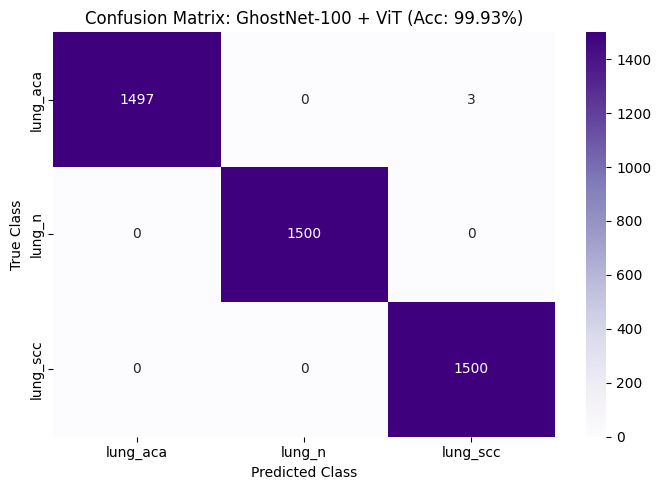

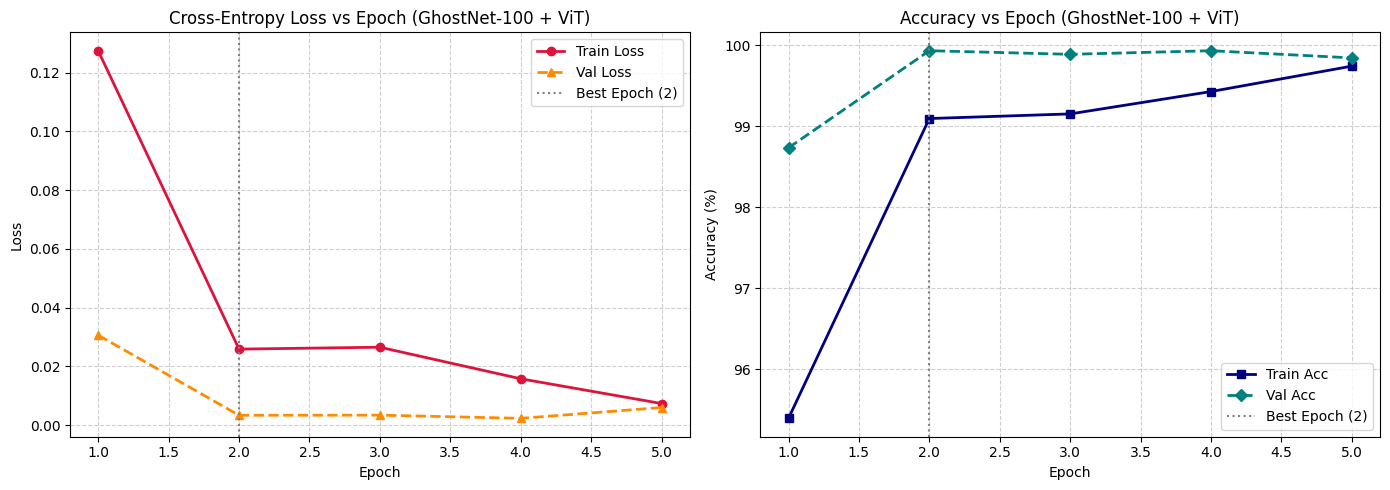

In [11]:
# 1. Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    results_hybrid['confusion_matrix'],
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True
)
plt.title(f"Confusion Matrix: GhostNet-100 + ViT (Acc: {results_hybrid['accuracy']*100:.2f}%)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("confusion_matrix_ghostnet100_vit.png", dpi=300)
plt.show()

# 2. Training Curves
epochs_trained = len(history_hybrid['train_loss'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
ax1.plot(range(1, epochs_trained + 1), history_hybrid['train_loss'], marker='o', color='crimson', lw=2, label="Train Loss")
ax1.plot(range(1, epochs_trained + 1), history_hybrid['val_loss'], marker='^', color='darkorange', lw=2, linestyle='--', label="Val Loss")
if best_hybrid_epoch > 0:
    ax1.axvline(best_hybrid_epoch, color='gray', linestyle=':', label=f"Best Epoch ({best_hybrid_epoch})")
ax1.set_title("Cross-Entropy Loss vs Epoch (GhostNet-100 + ViT)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# Accuracy Curve
ax2.plot(range(1, epochs_trained + 1), history_hybrid['train_acc'], marker='s', color='navy', lw=2, label="Train Acc")
ax2.plot(range(1, epochs_trained + 1), history_hybrid['val_acc'], marker='D', color='teal', lw=2, linestyle='--', label="Val Acc")
if best_hybrid_epoch > 0:
    ax2.axvline(best_hybrid_epoch, color='gray', linestyle=':', label=f"Best Epoch ({best_hybrid_epoch})")
ax2.set_title("Accuracy vs Epoch (GhostNet-100 + ViT)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("training_curves_ghostnet100_vit.png", dpi=300)
plt.show()

In [12]:
summary_comparison_data = [
    {
        "Metric": "Architecture",
        "GhostNet-100 Baseline": "GhostNet-100 (Standard)",
        "GhostNet-100 + ViT (Ours)": "GhostNet-100 + ViT Encoder (1-Layer)"
    },
    {
        "Metric": "Transformer Embed Dim / Heads",
        "GhostNet-100 Baseline": "N/A",
        "GhostNet-100 + ViT (Ours)": "256 / 4 Heads"
    },
    {
        "Metric": "Optimizer",
        "GhostNet-100 Baseline": "Adam (lr=1e-3)",
        "GhostNet-100 + ViT (Ours)": "AdamW (lr=2e-4, wd=1e-2)"
    },
    {
        "Metric": "LR Scheduler",
        "GhostNet-100 Baseline": "None",
        "GhostNet-100 + ViT (Ours)": "CosineAnnealingLR (T_max=12, eta_min=1e-6)"
    },
    {
        "Metric": "Early Stopping",
        "GhostNet-100 Baseline": "None (8 Epochs)",
        "GhostNet-100 + ViT (Ours)": "Patience=3 (Max 12 Epochs)"
    },
    {
        "Metric": "Test Accuracy (%)",
        "GhostNet-100 Baseline": f"{PREVIOUS_BASELINE_ACCURACY:.3f}%",
        "GhostNet-100 + ViT (Ours)": f"{results_hybrid['accuracy'] * 100:.4f}%"
    },
    {
        "Metric": "Macro Precision (%)",
        "GhostNet-100 Baseline": "97.6667%",
        "GhostNet-100 + ViT (Ours)": f"{results_hybrid['precision_macro'] * 100:.4f}%"
    },
    {
        "Metric": "Macro Recall / Sensitivity (%)",
        "GhostNet-100 Baseline": "97.6667%",
        "GhostNet-100 + ViT (Ours)": f"{results_hybrid['recall_macro'] * 100:.4f}%"
    },
    {
        "Metric": "Macro Specificity (%)",
        "GhostNet-100 Baseline": "98.8333%",
        "GhostNet-100 + ViT (Ours)": f"{results_hybrid['specificity_macro'] * 100:.4f}%"
    },
    {
        "Metric": "Macro F1-Score (%)",
        "GhostNet-100 Baseline": "97.6667%",
        "GhostNet-100 + ViT (Ours)": f"{results_hybrid['f1_macro'] * 100:.4f}%"
    },
    {
        "Metric": "Multiclass ROC-AUC (Macro OVR)",
        "GhostNet-100 Baseline": "0.9984",
        "GhostNet-100 + ViT (Ours)": f"{results_hybrid['roc_auc_macro']:.6f}"
    },
    {
        "Metric": "Checkpoint File",
        "GhostNet-100 Baseline": "ghostnet_100_non_augmented.pth",
        "GhostNet-100 + ViT (Ours)": CHECKPOINT_PATH
    }
]

df_hybrid_comparison = pd.DataFrame(summary_comparison_data)
print("=" * 80)
print("SIDE-BY-SIDE MODEL COMPARISON: GHOSTNET-100 BASELINE vs GHOSTNET-100 + ViT")
print("=" * 80)
print(df_hybrid_comparison.to_string(index=False))
print("=" * 80)

df_hybrid_comparison.to_csv("baseline_vs_ghostnet100_vit_comparison.csv", index=False)
df_hybrid_history = pd.DataFrame({
    "epoch": range(1, epochs_trained + 1),
    "train_loss": history_hybrid['train_loss'],
    "train_acc": history_hybrid['train_acc'],
    "val_loss": history_hybrid['val_loss'],
    "val_acc": history_hybrid['val_acc'],
    "lr": history_hybrid['learning_rates'],
    "epoch_time_s": history_hybrid['epoch_times']
})
df_hybrid_history.to_csv("training_history_ghostnet100_vit.csv", index=False)
print("\n[EXPORT] Comparison saved to 'baseline_vs_ghostnet100_vit_comparison.csv'")
print("[EXPORT] Training history saved to 'training_history_ghostnet100_vit.csv'")

SIDE-BY-SIDE MODEL COMPARISON: GHOSTNET-100 BASELINE vs GHOSTNET-100 + ViT
                        Metric          GhostNet-100 Baseline                                 GhostNet-100 + ViT (Ours)
                  Architecture        GhostNet-100 (Standard)                      GhostNet-100 + ViT Encoder (1-Layer)
 Transformer Embed Dim / Heads                            N/A                                             256 / 4 Heads
                     Optimizer                 Adam (lr=1e-3)                                  AdamW (lr=2e-4, wd=1e-2)
                  LR Scheduler                           None                CosineAnnealingLR (T_max=12, eta_min=1e-6)
                Early Stopping                None (8 Epochs)                                Patience=3 (Max 12 Epochs)
             Test Accuracy (%)                        97.667%                                                  99.9333%
           Macro Precision (%)                       97.6667%                        

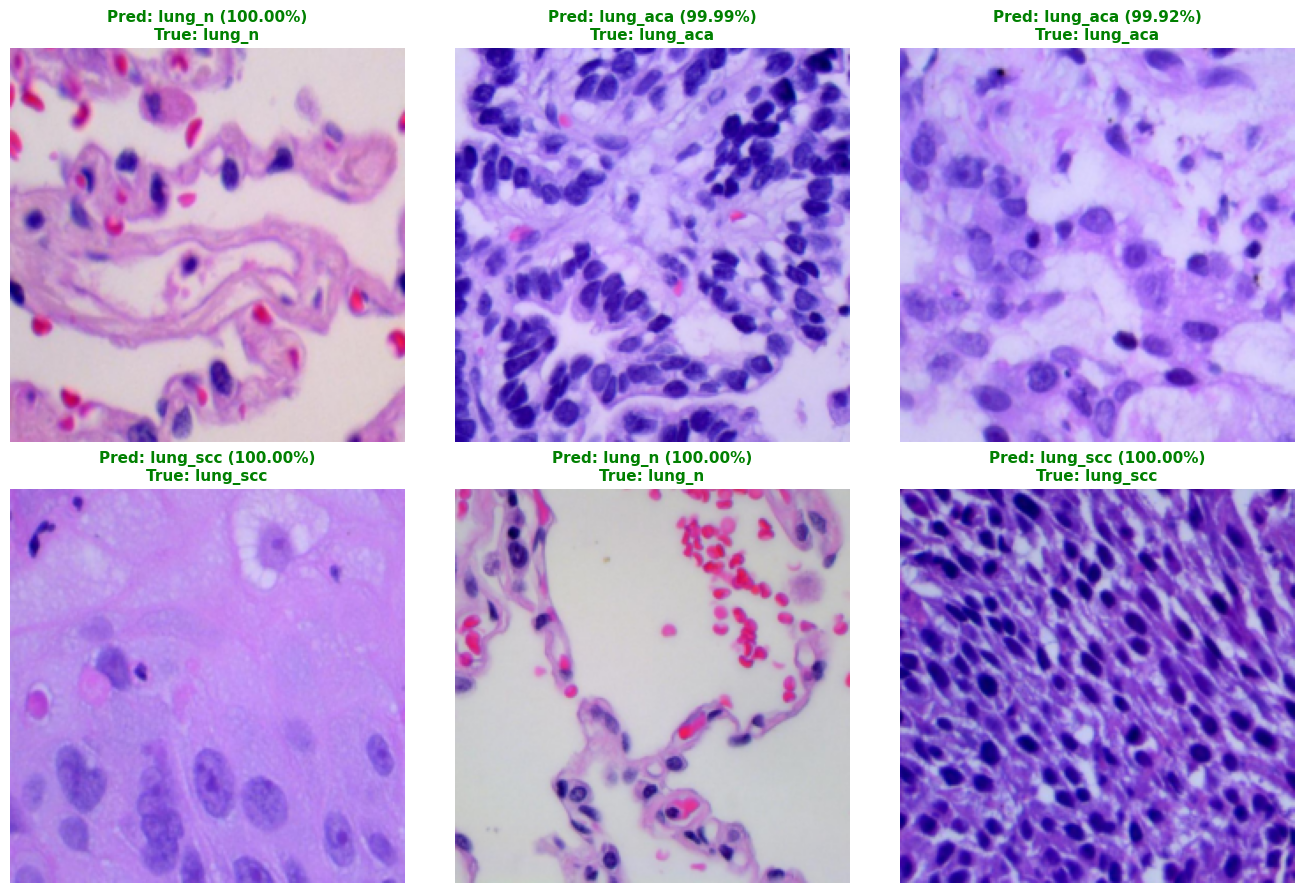

In [13]:
def visualize_test_predictions(model, dataset, num_samples=6, cols=3):
    model.eval()
    rows = (num_samples + cols - 1) // cols
    indices = random.sample(range(len(dataset)), num_samples)
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4.5))
    axes = axes.flatten() if num_samples > 1 else [axes]

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, true_label_idx = dataset[idx]
            input_tensor = img_tensor.unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred_label_idx = int(np.argmax(probs))
            confidence = probs[pred_label_idx] * 100.0

            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0.0, 1.0)

            true_name = IDX_TO_CLASS[int(true_label_idx)]
            pred_name = IDX_TO_CLASS[pred_label_idx]
            is_correct = (true_name == pred_name)

            axes[i].imshow(img_np)
            title_color = "green" if is_correct else "red"
            axes[i].set_title(
                f"Pred: {pred_name} ({confidence:.2f}%)\nTrue: {true_name}",
                fontsize=11,
                fontweight="bold",
                color=title_color
            )
            axes[i].axis("off")

    for j in range(num_samples, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

visualize_test_predictions(model_hybrid, test_dataset, num_samples=6, cols=3)